## Verification of Unbiased Gradient Estimation

### Objective

The objective of this experiment is to verify whether the stochastic gradient computed from randomly sampled mini-batches is an unbiased estimate of the true gradient computed using the entire training dataset.

If the average mini-batch gradient is close to the full-batch gradient, the stochastic gradient estimator can be considered approximately unbiased.

### Methodology

The verification is performed as follows:

1. Initialize the model with fixed random weights.
2. Compute the gradient using the entire training dataset (Full-batch Gradient).
3. Sample multiple random mini-batches of different sizes.
4. Compute the gradient for each mini-batch.
5. Average the mini-batch gradients.
6. Compare the average mini-batch gradient with the full-batch gradient using the relative gradient error.

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 

from src.utils import load_config
from src.data import get_dataloaders
from manual_nn.models import SimpleCNN
from torch.nn import CrossEntropyLoss
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [4]:
config = load_config(os.path.join(PROJECT_ROOT, "configs/data.yaml"))
model_cfg = load_config(os.path.join(PROJECT_ROOT, "configs/model.yaml"))

train_loader, _, _ = get_dataloaders(
    data_dir=config["root"],
    batch_size=len(get_dataloaders(
        data_dir=config["root"],
        batch_size=1,
    )[0].dataset),
    shuffle=False,
)

CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints/best_model.pth")
def load_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    layer_id = 0
    for layer in model.layers:
        if hasattr(layer, "weights"):
            layer.weights = checkpoint[f"layer_{layer_id}.weights"].to(device)
            layer.bias = checkpoint[f"layer_{layer_id}.bias"].to(device)
            layer_id += 1

    print(f"Loaded {layer_id} parameter layers from {checkpoint_path}")
    return model



model = SimpleCNN(model_cfg)
model = load_checkpoint(model, CHECKPOINT_PATH, 'cpu')
loss_fn = CrossEntropyLoss()

Loaded 4 parameter layers from /vision01_scratch/rajat/et-robo/problem1_mnist/checkpoints/best_model.pth


### Step 1: Compute the Full-batch Gradient

The gradient computed using the entire training dataset is treated as the reference gradient.

This gradient is compared against the average gradient computed from randomly sampled mini-batches of different sizes.

In [5]:
import torch
import torch.nn.functional as F

model.zero_grad()

for x, y in tqdm(train_loader):
    logits = model.forward(x)
    probs = F.softmax(logits, dim=1)
    targets = F.one_hot(y,num_classes=model_cfg["num_classes"]).float()
    grad_logits = (probs - targets) / y.size(0)
    model.backward(grad_logits)

full_grad = []

for grad in model.gradients():
    full_grad.append(grad.clone())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:40<00:00, 40.91s/it]


### Step 2: Compute Average Mini-batch Gradient

For each batch size, multiple random mini-batches are sampled.

The gradient for each mini-batch is computed, and the average gradient is calculated. This average is then compared with the full-batch gradient.

In [6]:
batch_sizes = [1,2,4,8,16,32,64,128,256,512]
num_trials = 200
relative_errors = {}

for batch_size in batch_sizes:
    print(f"Batch size:", batch_size)

    loader,_,_ = get_dataloaders(data_dir=config["root"], batch_size=batch_size, shuffle=True)

    avg_grad = [torch.zeros_like(g) for g in full_grad]
    count = 0

    for x,y in tqdm(loader, leave=False):

        model.zero_grad()

        logits = model.forward(x)
        probs = F.softmax(logits, dim=1)
        targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
        grad_logits = (probs - targets) / y.size(0)

        model.backward(grad_logits)

        for i,g in enumerate(model.gradients()):
            avg_grad[i] += g

        count += 1
        if count == num_trials:
            break

    avg_grad = [g / count for g in avg_grad]

    num = sum(torch.sum((g_avg - g_full) ** 2) for g_avg, g_full in zip(avg_grad, full_grad))
    den = sum(torch.sum(g_full ** 2) for g_full in full_grad)

    relative_errors[batch_size] = torch.sqrt(num / den).item()

Batch size: 1


Batch size: 2


Batch size: 4


Batch size: 8


Batch size: 16


Batch size: 32


Batch size: 64


Batch size: 128


Batch size: 256


Batch size: 512


### Step 3: Compare with the Full-batch Gradient

The average mini-batch gradient is compared with the full-batch gradient using the **Relative Gradient Error**,

$$
\frac{\|\bar{g}_{\mathrm{mini}}-g_{\mathrm{full}}\|_2}{\|g_{\mathrm{full}}\|_2}.
$$

A smaller value indicates that the average stochastic gradient is closer to the true gradient, providing empirical evidence for the unbiased gradient assumption.

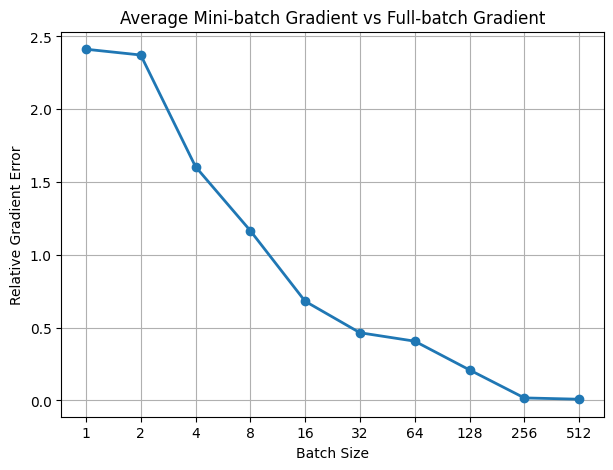

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    list(relative_errors.keys()),
    list(relative_errors.values()),
    marker="o",
    linewidth=2,
)

plt.xscale("log", base=2)
plt.xticks(batch_sizes, batch_sizes)
plt.xlabel("Batch Size")
plt.ylabel("Relative Gradient Error")
plt.title("Average Mini-batch Gradient vs Full-batch Gradient")
plt.grid(True)

plt.show()

### What does this figure tell?

- The relative gradient error decreases as the batch size increases.
- Larger mini-batches produce gradients that are closer to the full-batch gradient.
- The average gradient over multiple randomly sampled mini-batches closely approximates the true gradient.
- These observations provide empirical evidence that the stochastic gradient is approximately **unbiased** for the MNIST dataset.

In [9]:
list(relative_errors.values())[0],list(relative_errors.values())[-1]

(2.4126057624816895, 0.008611409924924374)